Till now in GCN we treated all neighbors as equal and aggregated information from each of them now we will explore a new approach called graph attention network like we will try to give importance to nieghbors of the node (attention) and then try to compute the embeddings of the node'

In the GCN the weights which we give for the node itself and to the aggregation of neighbors is purely dependent on no of neighbors does the node have in normalized one but here in GAT we will use node feature vector also and learn whether this node is important to our node not

GATs use a **trainable attention mechanism** $\alpha_{u,v}$ to dynamically decide how much to care about each neighbour:

$$m_{\mathcal{N}(u)} = \sum_{v \in \mathcal{N}(u)} \alpha_{u,v}\, h_v$$

The attention weight is computed as:

$$\alpha_{u,v} = \frac{\exp\!\left(a^\top [Wh_u \oplus Wh_v]\right)}{\sum_{v' \in \mathcal{N}(u)} \exp\!\left(a^\top [Wh_u \oplus Wh_{v'}]\right)}$$


The above are the formula which we will use to compute attention and each head will compute attention based on intial tranformation of 1433 vector to 8 dim vector and based on attention they will compute the aggregation of message from neighbor

In first layer it will use some weight matrix and transform that 1433 vector of each node into 8 dim and use that for computing the attention score next after passing through layer 1 we get some vectors of hid_dim*head dimension right we use to compute attention for next layer. Based on the head the transformation of 1433 vectors differs as each head have different weight matrix during layer1

In [1]:
#now we created a class right in src folder to implement this GAT we will import that
import os
import sys

# 1. Back out of the 'notebooks' directory into the root project directory
root_path = os.path.abspath(os.path.join(".."))

# 2. Map the absolute path straight to your 'src' folder
src_path = os.path.join(root_path, "src")

# 3. Inject the src path into sys.path so Python knows where to scan for your custom scripts
if src_path not in sys.path:
    sys.path.append(src_path)



print("Import successfull!!")

Import successfull!!


In [2]:
#loading the dataset 
import torch
from torch_geometric.datasets import Planetoid
#checking for GPU avaliablity 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Download or load the pre-cached Cora citation graph data package
dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0].to(device)

print(f"Input text features dimensions: {dataset.num_features}")
print(f"Output target category options: {dataset.num_classes}")
print(f"Total graph items inside 'data' packet: {data.num_nodes}")

Input text features dimensions: 1433
Output target category options: 7
Total graph items inside 'data' packet: 2708


In [3]:
import torch.nn.functional as F
import pandas as pd

from Experiment_GAT import AggregationGAT,AggregationGATO,cluster_embeddings_with_spectral,plot_tsne_comparison
from structural_baselines import compute_louvain_from_scratch,aggregate_graph_into_super_nodes,build_knn_similarity_graph,run_phase1_shuffling,full_hierarchical_louvain
#intializing the model using the function in class
gat_model = AggregationGAT(
    num_features=dataset.num_features, 
    num_classes=dataset.num_classes,
    hidden_dim=8,
    heads=8
).to(device)


optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()

#starting the training process of GAT
#here we are using transductive learning means giving entire graph as input to the model
#the assignment of nodes to train and test split happend during the loading of the dataset 

for epoch in range(1,201):
    gat_model.train()
    optimizer.zero_grad()
    out=gat_model(data.x,data.edge_index)
    #removing the unecessary gradients which were stored previously
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    #like callculating the loss only on train nodes
    #analyzing the performance for every 20 epoches 
    if epoch % 20 == 0:
        gat_model.eval()
        with torch.no_grad():
            pred = out.argmax(dim=1)
            train_acc = int((pred[data.train_mask] == data.y[data.train_mask]).sum()) / int(data.train_mask.sum())
            val_acc = int((pred[data.val_mask] == data.y[data.val_mask]).sum()) / int(data.val_mask.sum())
        print(f"Epoch {epoch:d} | Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}% | Val Acc: {val_acc*100:.4f}%")
#the model does not see the labels of val set during training and its is a type of transductive
#in transductive learning the situation of both val and test nodes is same 
# in inductive training train set is same and val set is depend of how u set up like while giving the input to model
# if val nodes also given then there labels will not be known or else they will also behave like complete test nodes
# test nodes is common they will not even present in graph to knwo their features nor their labels 

Epoch 20 | Train Loss: 0.8316 | Train Acc: 0.8214% | Val Acc: 65.6000%
Epoch 40 | Train Loss: 0.6233 | Train Acc: 0.8286% | Val Acc: 59.6000%
Epoch 60 | Train Loss: 0.4888 | Train Acc: 0.8429% | Val Acc: 58.0000%
Epoch 80 | Train Loss: 0.4924 | Train Acc: 0.8357% | Val Acc: 60.4000%
Epoch 100 | Train Loss: 0.3854 | Train Acc: 0.8714% | Val Acc: 56.4000%
Epoch 120 | Train Loss: 0.3679 | Train Acc: 0.8857% | Val Acc: 57.4000%
Epoch 140 | Train Loss: 0.4799 | Train Acc: 0.8500% | Val Acc: 62.6000%
Epoch 160 | Train Loss: 0.4489 | Train Acc: 0.8357% | Val Acc: 60.6000%
Epoch 180 | Train Loss: 0.3233 | Train Acc: 0.8929% | Val Acc: 59.2000%
Epoch 200 | Train Loss: 0.3154 | Train Acc: 0.8929% | Val Acc: 60.0000%


Epoch 30 | Loss: 0.7325 | Train: 79.3% | Val: 59.6% | Test: 60.4%
Epoch 60 | Loss: 0.4882 | Train: 85.7% | Val: 61.8% | Test: 62.0%
Epoch 90 | Loss: 0.3711 | Train: 88.6% | Val: 64.2% | Test: 65.7%
Epoch 120 | Loss: 0.4493 | Train: 82.1% | Val: 65.8% | Test: 65.8%
Epoch 150 | Loss: 0.4177 | Train: 84.3% | Val: 65.8% | Test: 64.8%
Epoch 180 | Loss: 0.4199 | Train: 82.1% | Val: 62.4% | Test: 65.7%
Epoch 210 | Loss: 0.3603 | Train: 85.0% | Val: 56.8% | Test: 61.0%
Epoch 240 | Loss: 0.3865 | Train: 87.1% | Val: 64.8% | Test: 66.4%
Epoch 270 | Loss: 0.4256 | Train: 83.6% | Val: 68.2% | Test: 65.9%
Epoch 300 | Loss: 0.2960 | Train: 90.0% | Val: 62.4% | Test: 60.7%


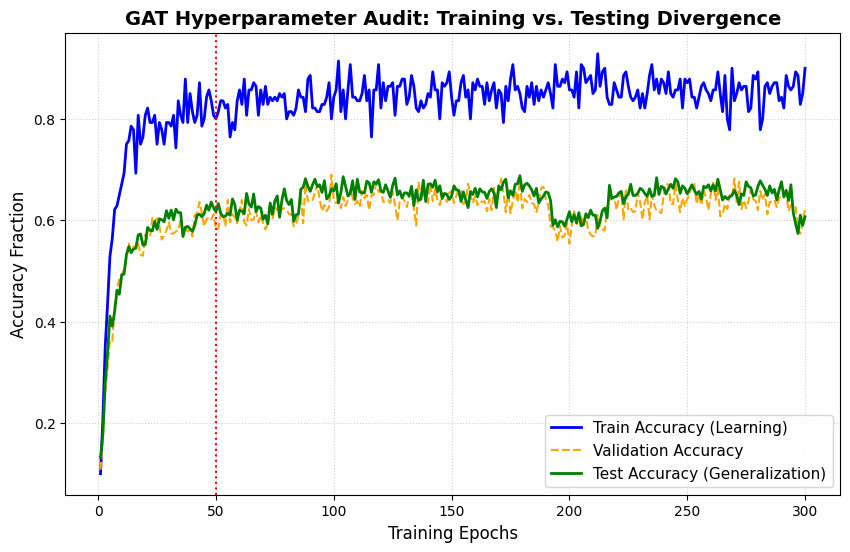

In [4]:
#in the above results we can see that train accuracy is increasing but test is decreasing now we will try to plot these in graph and check what is happening
import matplotlib.pyplot as plt
import pandas as pd

gat_model = AggregationGAT(dataset.num_features, dataset.num_classes, hidden_dim=8, heads=8).to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()
history = {
    "epoch": [], "train_loss": [],
    "train_acc": [], "val_acc": [], "test_acc": []
}
#now we will try to plot the train loss vs validation loss over the epoches
#train the model over 300 epoches 
for epoch in range(1, 301): # Increased to 300 epochs to give overfitting space to show up
    gat_model.train()
    optimizer.zero_grad()
    
    out = gat_model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    gat_model.eval()
    with torch.no_grad():
        pred = out.argmax(dim=1)
        #calculate the accuracy 
        t_acc = int((pred[data.train_mask] == data.y[data.train_mask]).sum()) / int(data.train_mask.sum())
        v_acc = int((pred[data.val_mask] == data.y[data.val_mask]).sum()) / int(data.val_mask.sum())
        te_acc = int((pred[data.test_mask] == data.y[data.test_mask]).sum()) / int(data.test_mask.sum())
        
        history["epoch"].append(epoch)
        history["train_loss"].append(loss.item())
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["test_acc"].append(te_acc)
        
    if epoch % 30 == 0:
        print(f"Epoch {epoch:d} | Loss: {loss.item():.4f} | Train: {t_acc*100:.1f}% | Val: {v_acc*100:.1f}% | Test: {te_acc*100:.1f}%")
#plotting the diagram
plt.figure(figsize=(10, 6))
plt.plot(history["epoch"], history["train_acc"], label="Train Accuracy (Learning)", color="blue", linewidth=2)
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy", color="orange", linestyle="--")
plt.plot(history["epoch"], history["test_acc"], label="Test Accuracy (Generalization)", color="green", linewidth=2)

plt.title("GAT Hyperparameter Audit: Training vs. Testing Divergence", fontsize=14, fontweight="bold")
plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Accuracy Fraction", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.axvline(x=50, color="red", linestyle=":", label="Potential Overfitting Tipping Point") # visual marker anchor
plt.show()

the red line is overfitting tripping point where till the point the all the three lines blue,green and yellow increasing but after that point at 50 epoch the green and yellow line completly hit the top and stopped increasing 

here we can see that train accuracy is more that test accuracy as the graph suggestes that graph is overfitting

but the reason it doesnt that much is because of our learning rate and decay rate which is helping to not to collapse

here now below we will try to do communtiy detection using k mean and spectral clustering also because till now in every method we have done community detection using k means here we are going to try do that with spectral clustering embeddings extractedd from GAT layer 1 and we will see the resutls 

Extracted embeddings shape: (2708, 64)
Community Detection on GAT Embeddings (dropout=0.6 model)
                 Clustering Strategy ARI Score NMI Score
                 K-Means (Spherical)    0.6077    0.5993
Spectral Clustering (Graph Geometry)    0.6030    0.6025


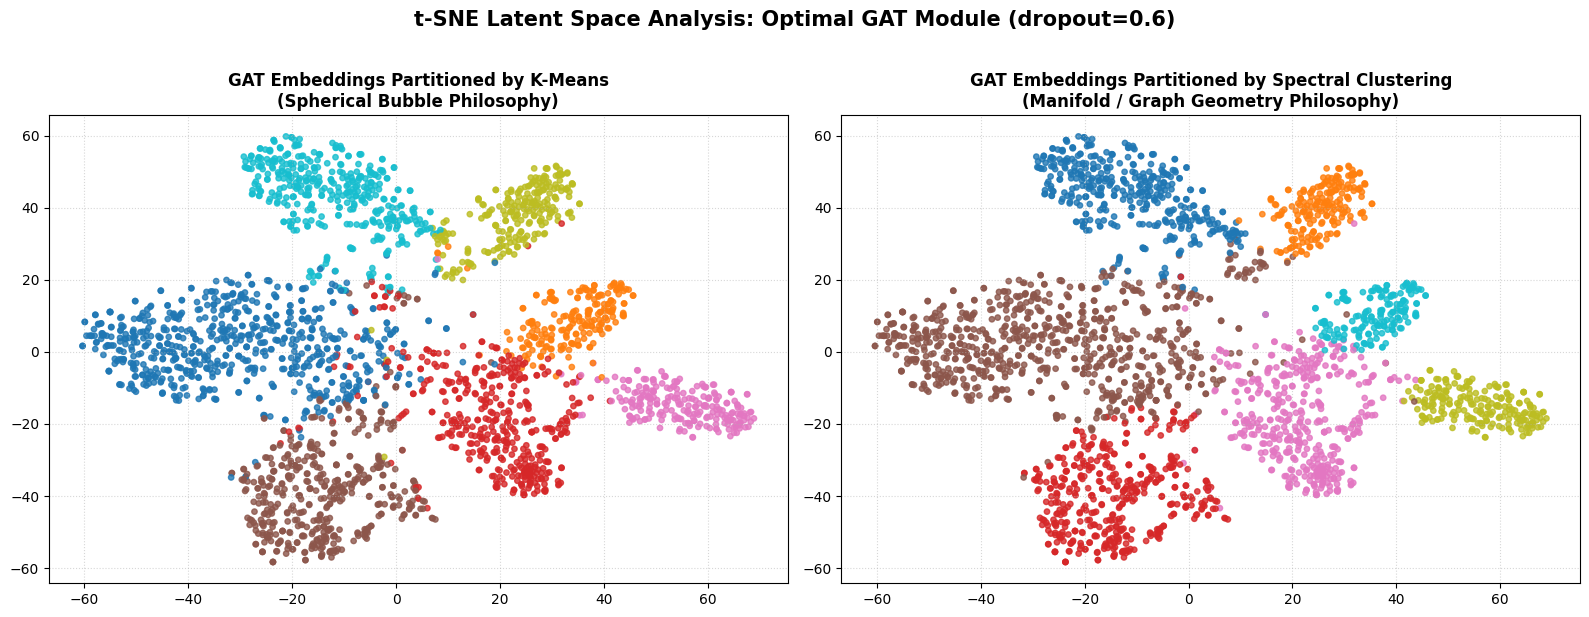

In [5]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# gat_model here is AggregationGAT (dropout=0.6) trained in cell 4
# layer1 outputs 8heads x 32dim = 256-dim vector per node
gat_model.eval()
with torch.no_grad():
    layer1_out = gat_model.layer1(data.x, data.edge_index)
    layer1_out = F.elu(layer1_out)
    gat_embeddings_np = layer1_out.cpu().numpy()

true_labels_np = data.y.cpu().numpy()
print(f"Extracted embeddings shape: {gat_embeddings_np.shape}")

# K-Means clustering on GAT embeddings
kmeans_clusters = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(gat_embeddings_np)
kmeans_ari = adjusted_rand_score(true_labels_np, kmeans_clusters)
kmeans_nmi = normalized_mutual_info_score(true_labels_np, kmeans_clusters)

# Spectral clustering on GAT embeddings
# captures spectral_clusters variable properly this time
spectral_ari, spectral_nmi, spectral_clusters = cluster_embeddings_with_spectral(
    embeddings_np=gat_embeddings_np,
    true_labels_np=true_labels_np,
    num_clusters=7,
    n_neighbors=10
)

results = {
    "Clustering Strategy": ["K-Means (Spherical)", "Spectral Clustering (Graph Geometry)"],
    "ARI Score": [f"{kmeans_ari:.4f}", f"{spectral_ari:.4f}"],
    "NMI Score": [f"{kmeans_nmi:.4f}", f"{spectral_nmi:.4f}"]
}
print("Community Detection on GAT Embeddings (dropout=0.6 model)")
print(pd.DataFrame(results).to_string(index=False))

# t-SNE plot comparing K-Means vs Spectral partition on the same 2D embedding space
embeddings_2d = plot_tsne_comparison(
    embeddings_np=gat_embeddings_np,
    kmeans_labels=kmeans_clusters,
    spectral_labels=spectral_clusters,
    true_labels=true_labels_np,
    title_suffix="Optimal GAT Module (dropout=0.6)"
)

The NMI ( normalized mutual information ) which we use a metric for evaluating the communtiy detection this metric is completely based on entropy which is termed as uncertainity like when ur 100% sure about a thing then this entropy is 0 or lese if the occurrence of that thing is random then we can say there is some value for entopy now below we will see how the value gets calculated wih an example


Understanding Entropy ($H$)Think of Entropy as a measure of surprise. If an outcome is completely guaranteed, entropy is $0$ (zero surprise). If an outcome is totally unpredictable, entropy is high.The formula for the entropy of a distribution $X$ is:$$H(X) = -\sum_{x} P(x) \log_2 P(x)$$Complete Concrete ExampleImagine we have a tiny graph of 4 papers.Ground Truth ($Y$): 2 papers belong to Neural Networks ($NN$), 2 papers belong to Theory ($T$).Our Predictions ($C$): Our clustering algorithm groups them into Cluster $A$ and Cluster $B$.1. Calculate Ground Truth Entropy $H(Y)$The probability of picking an $NN$ paper is $2/4 = 0.5$. The probability of picking a $T$ paper is $2/4 = 0.5$.$$H(Y) = -\left[ 0.5 \log_2(0.5) + 0.5 \log_2(0.5) \right] = -\left[ 0.5(-1) + 0.5(-1) \right] = 1.0 \text{ bit}$$This means there is exactly $1$ bit of uncertainty in the true labels.Case A: The Perfect Clustering RunImagine our algorithm perfectly groups them: Cluster $A$ gets the 2 $NN$ papers, and Cluster $B$ gets the 2 $T$ papers.If I tell you a paper is in Cluster $A$, you are 100% certain it is an $NN$ paper. The uncertainty drops to $0$.The Mutual Information $I(Y;C)$—which is the uncertainty removed—is exactly $1.0$.$$\text{NMI} = \frac{I(Y;C)}{\sqrt{H(Y)H(C)}} = \frac{1.0}{\sqrt{1.0 \times 1.0}} = 1.0000 \text{ (Perfect Score)}$$Case B: The Imperfect/Random Clustering RunNow imagine our algorithm completely fails. Cluster $A$ gets 1 $NN$ paper and 1 $T$ paper. Cluster $B$ gets 1 $NN$ paper and 1 $T$ paper.Let's calculate the uncertainty remaining. If I tell you a paper is in Cluster $A$, what is its topic? It is still a 50/50 guess ($1$ $NN$ and $1$ $T$). Knowing the cluster assignment gave you absolutely zero new information. * The uncertainty removed ($I(Y;C)$) is $0$.$$\text{NMI} = \frac{0}{\sqrt{1.0 \times 1.0}} = 0.0000 \text{ (Completely Random)}$$NMI scales this shared information cleanly between 0.0 (zero shared information) and 1.0 (perfect alignment), giving you an exceptionally reliable metric that is completely shielded from variations in absolute cluster sizes!  


In case 1 during perfect clustering case we were told that uncertainity becomes 0 right then the denominator should become zero right but there are two different type of uncertainity one is conditional uncertainity and second one is standalone uncertainity here conditional becomes but we are using standalone

T-SNE with full name stochastic neighbor embedding which is used for dimensionality reduction of out node embeddings first what it does is convert all the embeddings into 2d and then place them on a 2d plane after that compute the probability of two nodes can be closer and then using the distance between them and finally place or pull the nodes together whose probability is high . the distances it measures based on the intial dimensional vectors only like 256dim vector of hidden layer 1 in this case


In your 256-dimensional GAT embedding space, t-SNE measures the straight-line (Euclidean) distance between Node $i$ and Node $j$, written as $d(x_i, x_j)^2$.To convert this raw distance into a clean probability, it places a symmetric bell curve (Gaussian distribution) over Node $i$.$$\text{Probability } p_{j|i} = \frac{\exp\left(-\frac{d(x_i, x_j)^2}{2\sigma_i^2}\right)}{\sum_{k \neq i} \exp\left(-\frac{d(x_i, x_k)^2}{2\sigma_i^2}\right)}$$Simple Interpretation: If the distance $d(x_i, x_j)$ is very small (they are close neighbors), the numerator is large, meaning a high probability ($p_{j|i}$) that Node $i$ would pick Node $j$ as its neighbor.If they are far apart, the probability drops to near $0$. ($\sigma_i$ is a scaling factor based on your chosen perplexity).

we are using this labels of nodes for doing node classifcation and evaluating the model using train,test and val accuracy which is a supervised learning but our main task is to do community detection right so in here we can this cora dataset for both node classification and comuntiy detection ectracting the embeddings from layer 1 and do means k means or passing them to output layer 2 to get final probability scores .

In node classification we already know the labels of some nodes (train) and then we try to predict the other ones so that is why this will be termed as semi supervised learning .

see while doing this task to predict the node labels where the network never asked to detect the communities it only tried to classify nodes but on doing it so it produces the node embeddings which will bring the similar nodes closer which often helps us in community detection.

we dont train our model directly on what is our goal instead we we train it on another task that helps to acheive final goal

Now we wanted to try louvian algorithm instead of this spectral clustering on the embeddings of GAT hidden layer and check the results for that first we have to understand the concept of modularity and then how the louvian algorithm works

In order to implement louvian algorithm first we need to understand about modularity and how it works ,

It measures how many connections are present inside your each community compared to total edges in the graph. The formula is:

$$
Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)
$$

$A_{ij}$ is the weight of the edge between node $i$ and node $j$ in your embedding similarity graph.

$k_i$ and $k_j$ are the sums of the weights of the edges connected to node $i$ and node $j$.

$m$ is the total sum of all edge weights in the entire graph.

$\delta(c_i, c_j)$ is a gatekeeper variable: it equals $1$ if node $i$ and node $j$ belong to the same cluster, and $0$ if they are in different clusters.

When a node shifts communities in Phase 1, the greedy change in modularity ($\Delta Q$) is computed incredibly fast using this localized variation:

$$
\Delta Q =
\left[
\frac{\Sigma_{in} + 2k_{i,in}}{2m}
-
\left(\frac{\Sigma_{tot} + k_i}{2m}\right)^2
\right]
-
\left[
\frac{\Sigma_{in}}{2m}
-
\left(\frac{\Sigma_{tot}}{2m}\right)^2
-
\left(\frac{k_i}{2m}\right)^2
\right]
$$

The above formula change in modularity is the heart of louvian algorithm it only answers one question whether moving a node from one community to other will increase the modularity or not if yes it will make that move or lese it wont take that . 

The terms Sigma(in) means total no of edges present in that target community and k(i) is no of edges does the current node i has with target community Sigma(total) is the sum of degrees of all nodes present in the community and first bracket is modularity if we move the node to target community and second bracket is what we does not.

If the values result in positive then it is good make the move like move the node to target community or else keep the node in current community only.

This algorithm consists of two phases like first one is it will make the above node movement until no movement is possible and then it will make super nodes called node Aggregation in order to detect final communities

In [6]:
import scipy.sparse as sp
import numpy as np

# 1. Ensure your model is in evaluation mode
gat_model.eval()

# 2. Extract your GAT Layer 1 hidden representations
# (Assuming 'x' represents features and 'edge_index' is your graph structure)
with torch.no_grad():
    # Adjust this line to match your exact GAT forward pass layer return variable
    layer1_embeddings = gat_model.layer1(data.x, data.edge_index) 
    
    # Convert tensors safely to a standard CPU NumPy array
    embeddings_np = layer1_embeddings.cpu().numpy()

# 3. Call your custom scratch Louvain implementation pipeline
print("Running Custom Hierarchical Louvain Algorithm from scratch...")
louvain_labels = full_hierarchical_louvain(embeddings_np, n_neighbors=15)

# 4. Print out your verification metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
# Assuming 'true_labels' is your ground truth variable from the Cora dataset
ari = adjusted_rand_score(true_labels_np, louvain_labels)
nmi = normalized_mutual_info_score(true_labels_np, louvain_labels)

print(f"Custom Louvain Metrics -> ARI Score: {ari:.4f} | NMI Score: {nmi:.4f}")
print(f"Number of ground-truth classes: {len(np.unique(true_labels_np))}")
print(f"Number of communities Louvain found: {len(np.unique(louvain_labels))}")

Running Custom Hierarchical Louvain Algorithm from scratch...
Custom Louvain Metrics -> ARI Score: 0.2083 | NMI Score: 0.4634
Number of ground-truth classes: 7
Number of communities Louvain found: 33


Here the ARI and NMI are very bad because in previous k means and spectral clustering we are explicitly saying the algorithms to detect 7 communities as we already know there will be 7 in this cora dataset right but in the louvian algorithm case we did not say it so the reason for very low ARI is it detected more no of communities than the graph actually has  . i mean here the louvian algorithm did a high resolution map like it even detected the sub communitites but ARI only maps to actual communties so thats why ARI is so much reduced.

Epoch 30 | Loss: 1.1181 | Train: 68.6% | Val: 53.8% | Test: 54.6%
Epoch 60 | Loss: 0.7349 | Train: 76.4% | Val: 54.0% | Test: 54.9%
Epoch 90 | Loss: 0.6982 | Train: 77.1% | Val: 55.6% | Test: 58.1%
Epoch 120 | Loss: 0.6794 | Train: 76.4% | Val: 57.2% | Test: 58.3%
Epoch 150 | Loss: 0.6066 | Train: 82.1% | Val: 55.4% | Test: 57.2%
Epoch 180 | Loss: 0.6917 | Train: 77.1% | Val: 53.4% | Test: 58.3%
Epoch 210 | Loss: 0.6884 | Train: 74.3% | Val: 59.8% | Test: 57.8%
Epoch 240 | Loss: 0.7558 | Train: 80.7% | Val: 55.0% | Test: 54.5%
Epoch 270 | Loss: 0.7172 | Train: 79.3% | Val: 51.6% | Test: 55.4%
Epoch 300 | Loss: 0.5325 | Train: 84.3% | Val: 55.6% | Test: 57.3%


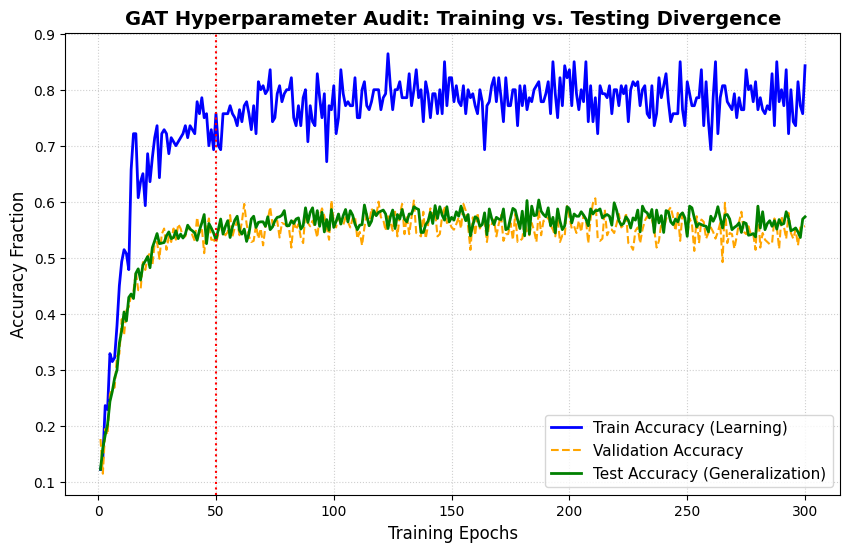

In [7]:
#here below as the model overfit above we saw right we will try to increase the dropout and observe the result 
gat_model = AggregationGATO(dataset.num_features, dataset.num_classes, hidden_dim=8, heads=8).to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-3)
criterion = torch.nn.NLLLoss()
history = {
    "epoch": [], "train_loss": [],
    "train_acc": [], "val_acc": [], "test_acc": []
}
#now we will try to plot the train loss vs validation loss over the epoches
#train the model over 300 epoches 
for epoch in range(1, 301): # Increased to 300 epochs to give overfitting space to show up
    gat_model.train()
    optimizer.zero_grad()
    
    out = gat_model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    gat_model.eval()
    with torch.no_grad():
        pred = out.argmax(dim=1)
        #calculate the accuracy 
        t_acc = int((pred[data.train_mask] == data.y[data.train_mask]).sum()) / int(data.train_mask.sum())
        v_acc = int((pred[data.val_mask] == data.y[data.val_mask]).sum()) / int(data.val_mask.sum())
        te_acc = int((pred[data.test_mask] == data.y[data.test_mask]).sum()) / int(data.test_mask.sum())
        
        history["epoch"].append(epoch)
        history["train_loss"].append(loss.item())
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["test_acc"].append(te_acc)
        
    if epoch % 30 == 0:
        print(f"Epoch {epoch:d} | Loss: {loss.item():.4f} | Train: {t_acc*100:.1f}% | Val: {v_acc*100:.1f}% | Test: {te_acc*100:.1f}%")
#plotting the diagram
plt.figure(figsize=(10, 6))
plt.plot(history["epoch"], history["train_acc"], label="Train Accuracy (Learning)", color="blue", linewidth=2)
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy", color="orange", linestyle="--")
plt.plot(history["epoch"], history["test_acc"], label="Test Accuracy (Generalization)", color="green", linewidth=2)

plt.title("GAT Hyperparameter Audit: Training vs. Testing Divergence", fontsize=14, fontweight="bold")
plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Accuracy Fraction", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.axvline(x=50, color="red", linestyle=":", label="Potential Overfitting Tipping Point") # visual marker anchor
plt.show()

here the model is underfitting as we can see that when we increased the dropout and decay rate so that model can generalize well and we thaught that accuracy will increase but unfortunately it started underfitting and our results even went to worse 